# 07 - Modeling: Laptop Price Prediction

This notebook trains and evaluates regression models for laptop price prediction using the fully preprocessed dataset.

Main principles:
- Use one fixed 80/20 train/test split for both targets.
- Never include `price` or `logprice` in the feature matrix.
- Train each model twice: once on `price`, once on `logprice`.
- Convert `logprice` predictions back to the original price scale before the main comparison.
- Save clean artifacts for downstream analysis notebooks.

## 1. Import libraries

Cell này gom các thư viện cần thiết cho toàn bộ quy trình modeling: xử lý dữ liệu, chia tập train/test, huấn luyện mô hình, tính metric, trực quan hóa và lưu artifact. Các warning không quan trọng như `ConvergenceWarning` được ẩn để notebook gọn hơn, nhưng các lỗi train model thật sự vẫn được bắt và in rõ ràng ở phần training.

In [123]:
from __future__ import annotations

import importlib
import pickle
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 2. Configuration

In [124]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Choose the inverse transformation used to convert log predictions back to price.
# Use 'log1p' if logprice = np.log1p(price), or 'log' if logprice = np.log(price).
LOG_TRANSFORM = 'log1p'
CLIP_NEGATIVE_PREDICTIONS = True

PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed.csv'

ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'modeling'
METRICS_DIR = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
PLOTS_DIR = ARTIFACT_DIR / 'plots'
MODELS_DIR = ARTIFACT_DIR / 'models'
FEATURE_IMPORTANCE_DIR = ARTIFACT_DIR / 'feature_importance'

for directory in [METRICS_DIR, PREDICTIONS_DIR, PLOTS_DIR, MODELS_DIR, FEATURE_IMPORTANCE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {
    'Linear Regression': 'LinearRegression',
    'Ridge': 'Ridge',
    'Lasso': 'Lasso',
    'ElasticNet': 'ElasticNet',
    'Random Forest': 'RandomForest',
    'Extra Trees': 'ExtraTrees',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM',
    'CatBoost': 'CatBoost',
}

print(f'Data path: {DATA_PATH}')
print(f'Artifacts path: {ARTIFACT_DIR}')

Data path: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
Artifacts path: Y:\Python\Laptop-Price-Prediction\artifacts\modeling


## 3. Load preprocessed data

Dữ liệu đầu vào được giả định là bản đã preprocessing hoàn chỉnh, vì vậy notebook không làm lại EDA hay feature engineering. Hàm `standardize_target_columns` chỉ chuẩn hóa tên target về `price` và `logprice`; với file hiện tại, hai cột gốc là `target_price` và `log_target_price`, nên bước này giúp notebook vừa đúng yêu cầu modeling vừa chạy được với schema thực tế.

In [125]:
df = pd.read_csv(DATA_PATH)

required_targets = {'target_price', 'log_target_price'}
missing_targets = required_targets.difference(df.columns)
if missing_targets:
    raise ValueError(f'Missing required target columns: {sorted(missing_targets)}')

print(f'Dataset shape: {df.shape}')
display(df.head())
display(df[['target_price', 'log_target_price']].describe())

Dataset shape: (7304, 60)


,ram_gb,storage_gb,screen_size_inch,brand_is_rare,model_is_rare,ram_missing,storage_missing,screen_missing,cpu_missing,gpu_missing,cpu_tier_encoded,gpu_tier_ord_filled,ram_level,storage_level,screen_size_level,brand_ASUS,brand_Acer,brand_Apple,brand_Dell,brand_HP,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Other,model_Elitebook,model_Inspiron,model_Latitude,model_MacBook Air,model_MacBook Air M1,model_MacBook Pro,model_MacBook Pro M1,model_Nitro 5,model_Other,model_Precision,model_ProBook,model_ThinkPad,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,cpu_brand_Microsoft SQ,cpu_brand_Other,cpu_brand_Qualcomm,storage_type_HDD,storage_type_Other,storage_type_SSD,storage_type_SSD + HDD,condition_Mới,condition_Unknown,condition_Đã sử dụng (chưa sửa chữa),condition_Đã sử dụng (qua sửa chữa),warranty_Active,warranty_Expired,warranty_Manufacturer,warranty_not_active,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info,target_price,log_target_price
0,16.0000,256.0000,13.9500,0,0,0,0,0,0,0,6,0,4,2,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,"9,990,000.0000",16.1171
1,8.0000,127.0000,15.9500,0,0,0,0,0,0,0,3,0,3,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,"4,500,000.0000",15.3196
2,8.0000,512.0000,11.9500,0,0,0,0,0,0,0,6,0,3,3,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,"3,500,000.0000",15.0683
3,32.0000,512.0000,13.9500,0,0,0,0,0,1,0,0,0,5,3,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,"37,500,000.0000",17.4399
4,16.0000,256.0000,13.9500,0,0,0,0,0,1,0,0,0,4,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,"7,990,000.0000",15.8937


,target_price,log_target_price
count,"7,304.0000","7,304.0000"
mean,"14,940,304.5137",16.1329
std,"15,325,606.7565",0.8921
min,"1,000,000.0000",13.8155
25%,"5,600,000.0000",15.5383
50%,"10,500,000.0000",16.1669
75%,"18,800,000.0000",16.7494
max,"179,400,000.0000",19.0051


## 4. Define feature matrix and targets

Đây là bước quan trọng nhất để tránh data leakage. Feature matrix `X` được tạo bằng cách loại bỏ cả `price` và `logprice`, còn hai target được giữ riêng biệt: `y_price` dùng cho mô hình dự đoán giá trực tiếp, `y_logprice` dùng cho mô hình học trên log scale. Notebook cũng kiểm tra lại rằng không còn target nào nằm trong `X` trước khi train.

In [126]:
TARGET_COLUMNS = ['target_price', 'log_target_price']

X = df.drop(columns=TARGET_COLUMNS)
y_price = df['target_price']
y_logprice = df['log_target_price']

leakage_columns = {'target_price', 'log_target_price'}.intersection(X.columns)
if leakage_columns:
    raise ValueError(f'Data leakage detected in X: {sorted(leakage_columns)}')

non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(
        'All features should be numeric after preprocessing. '
        f'Non-numeric columns found: {non_numeric_columns}'
    )

feature_names = X.columns.tolist()

print(f'Feature matrix shape: {X.shape}')
print(f'Price target shape: {y_price.shape}')
print(f'Logprice target shape: {y_logprice.shape}')

Feature matrix shape: (7304, 58)
Price target shape: (7304,)
Logprice target shape: (7304,)


## 5. Train/test split 80/20

Cùng một lệnh `train_test_split` được dùng đồng thời cho `X`, `y_price` và `y_logprice`. Cách này đảm bảo mọi model, dù train trên target nào, đều được so sánh trên đúng cùng tập test và cùng các sample, giúp kết quả giữa `price` và `logprice` công bằng hơn.

In [127]:
X_train, X_test, y_price_train, y_price_test, y_log_train, y_log_test = train_test_split(
    X,
    y_price,
    y_logprice,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_price_train: {y_price_train.shape}')
print(f'y_log_train  : {y_log_train.shape}')
print('Same split is used for price and logprice targets.')

X_train: (5843, 58)
X_test : (1461, 58)
y_price_train: (5843,)
y_log_train  : (5843,)
Same split is used for price and logprice targets.


## 6. Define metrics functions

Các metric chính gồm MAE, RMSE, R2, MAPE, Median Absolute Error và Max Error. Với bảng so sánh chính, tất cả metric luôn được tính trên cùng đơn vị là giá laptop thật (`price scale`), vì đây là đơn vị có ý nghĩa trực tiếp nhất khi báo cáo sai số dự đoán.

In [128]:
def calculate_metrics(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Calculate regression metrics on the same scale for y_true and y_pred."""
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)

    return {
        'mae': mean_absolute_error(y_true_arr, y_pred_arr),
        'rmse': root_mean_squared_error(y_true_arr, y_pred_arr),
        'r2': r2_score(y_true_arr, y_pred_arr),
        'mape': mean_absolute_percentage_error(y_true_arr, y_pred_arr),
        'median_ae': median_absolute_error(y_true_arr, y_pred_arr),
        'max_error': max_error(y_true_arr, y_pred_arr),
    }

## 7. Define inverse log transform function

Mô hình train bằng `logprice` sẽ predict ra giá trị trên log scale. Trước khi so sánh với `y_price_test`, prediction này bắt buộc được inverse về price scale bằng `np.expm1` hoặc `np.exp` tùy cấu hình. Notebook cũng clip prediction âm về 0 để tránh các giá trị không hợp lý sau inverse transform.

In [129]:
def inverse_log_transform(y_pred_log: np.ndarray, method: str = 'log1p') -> np.ndarray:
    """Convert log-scale predictions back to price scale."""
    y_pred_log = np.asarray(y_pred_log, dtype=float)

    if method == 'log1p':
        y_pred_price = np.expm1(y_pred_log)
    elif method == 'log':
        y_pred_price = np.exp(y_pred_log)
    else:
        raise ValueError("method must be either 'log1p' or 'log'")

    if CLIP_NEGATIVE_PREDICTIONS:
        y_pred_price = np.maximum(y_pred_price, 0)

    return y_pred_price


def infer_log_transform(y_price_values: pd.Series, y_log_values: pd.Series) -> pd.DataFrame:
    """Quick diagnostic comparing configured transform to observed target values."""
    price = np.asarray(y_price_values, dtype=float)
    log_values = np.asarray(y_log_values, dtype=float)
    diagnostics = pd.DataFrame(
        {
            'method': ['log1p', 'log'],
            'mean_abs_difference': [
                np.mean(np.abs(np.log1p(price) - log_values)),
                np.mean(np.abs(np.log(price) - log_values)),
            ],
        }
    ).sort_values('mean_abs_difference')
    return diagnostics

log_transform_diagnostics = infer_log_transform(y_price, y_logprice)
display(log_transform_diagnostics)
print(f'Configured LOG_TRANSFORM = {LOG_TRANSFORM!r}')

,method,mean_abs_difference
0,log1p,0.0000
1,log,0.0000


Configured LOG_TRANSFORM = 'log1p'


## 8. Define models

Danh sách model được định nghĩa theo một cấu trúc thống nhất gồm tên model, loại model và estimator. Các model tuyến tính được đặt trong pipeline có `StandardScaler` vì chúng nhạy với thang đo feature; các tree-based model không cần scaler. XGBoost, LightGBM và CatBoost là optional: nếu môi trường chưa cài, notebook chỉ cảnh báo và bỏ qua thay vì dừng toàn bộ quy trình.

In [130]:
def optional_import(module_name: str, class_name: str) -> Optional[Any]:
    """Import optional model classes without crashing the notebook."""
    try:
        module = importlib.import_module(module_name)
        return getattr(module, class_name)
    except Exception as exc:
        print(f'Warning: {class_name} is not available and will be skipped. Details: {exc}')
        return None


def make_linear_pipeline(estimator: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', estimator),
        ]
    )


def define_models() -> List[Dict[str, Any]]:
    models: List[Dict[str, Any]] = [
        {
            'model_name': 'Linear Regression',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(LinearRegression()),
        },
        {
            'model_name': 'Ridge',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Ridge(alpha=1.0)),
        },
        {
            'model_name': 'Lasso',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Lasso(alpha=0.001, max_iter=10000)),
        },
        {
            'model_name': 'ElasticNet',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)),
        },
        {
            'model_name': 'Random Forest',
            'model_type': 'tree_ensemble',
            'estimator': RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
        {
            'model_name': 'Extra Trees',
            'model_type': 'tree_ensemble',
            'estimator': ExtraTreesRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
    ]

    XGBRegressor = optional_import('xgboost', 'XGBRegressor')
    if XGBRegressor is not None:
        models.append(
            {
                'model_name': 'XGBoost',
                'model_type': 'gradient_boosting',
                'estimator': XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    objective='reg:squarederror',
                    n_jobs=-1,
                ),
            }
        )

    LGBMRegressor = optional_import('lightgbm', 'LGBMRegressor')
    if LGBMRegressor is not None:
        models.append(
            {
                'model_name': 'LightGBM',
                'model_type': 'gradient_boosting',
                'estimator': LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            }
        )

    CatBoostRegressor = optional_import('catboost', 'CatBoostRegressor')
    if CatBoostRegressor is not None:
        models.append(
            {
                'model_name': 'CatBoost',
                'model_type': 'gradient_boosting',
                'estimator': CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    random_seed=RANDOM_STATE,
                    verbose=0,
                    allow_writing_files=False,
                ),
            }
        )

    return models


model_specs = define_models()
print(f'Number of models to train: {len(model_specs)}')
print([spec['model_name'] for spec in model_specs])

Number of models to train: 8
['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Extra Trees', 'LightGBM', 'CatBoost']


## Helper functions for training, persistence, plots, and feature importance

Các hàm helper giúp notebook ngắn gọn và dễ bảo trì hơn. Một hàm training duy nhất được dùng cho cả hai target, trong đó logic khác biệt nằm ở bước hậu xử lý prediction: target `price` được dùng trực tiếp, còn target `logprice` được inverse về price scale trước khi tính metric và lưu prediction.

In [131]:
def safe_filename(model_name: str, target_used: str) -> str:
    base_name = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(' ', ''))
    return f'{base_name}_{target_used}'


def save_model(model: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, path)


def train_and_evaluate_model(
    model: Any,
    model_name: str,
    model_type: str,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test_price: pd.Series,
    target_used: str,
    y_test_log: Optional[pd.Series] = None,
) -> Tuple[Any, Dict[str, Any], np.ndarray, Optional[Dict[str, float]]]:
    """Fit a model and evaluate predictions on price scale."""
    estimator = clone(model)

    start_train = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_time_sec = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    raw_pred = estimator.predict(X_test)
    predict_time_sec = time.perf_counter() - start_pred

    log_scale_metrics = None
    if target_used == 'log_target_price':
        y_pred_price = inverse_log_transform(raw_pred, method=LOG_TRANSFORM)
        if y_test_log is not None:
            log_scale_metrics = calculate_metrics(y_test_log, raw_pred)
    elif target_used == 'target_price':
        y_pred_price = np.asarray(raw_pred, dtype=float)
        if CLIP_NEGATIVE_PREDICTIONS:
            y_pred_price = np.maximum(y_pred_price, 0)
    else:
        raise ValueError("target_used must be 'target_price' or 'log_target_price'")

    metrics = calculate_metrics(y_test_price, y_pred_price)
    metrics.update(
        {
            'model_name': model_name,
            'model_type': model_type,
            'target_used': target_used,
            'evaluation_scale': 'target_price',
            'train_time_sec': train_time_sec,
            'predict_time_sec': predict_time_sec,
        }
    )

    return estimator, metrics, y_pred_price, log_scale_metrics


def plot_metric_comparison(metrics_df: pd.DataFrame, metric_name: str) -> None:
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    plot_df = metrics_df.sort_values(metric_name, ascending=(metric_name != 'r2'))

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=plot_df, x='model_name', y=metric_name, hue='target_used')
    ax.set_title(f'{metric_label} Comparison by Model and Target')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    plt.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{metric_name}_comparison.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_actual_vs_predicted(y_true: pd.Series, y_pred: np.ndarray, model_name: str, target_used: str) -> None:
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.55, edgecolor=None)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {model_name} ({target_used})')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'actual_vs_predicted_{safe_filename(model_name, target_used)}.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_residuals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.55,
        edgecolor=None,
        ax=ax
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Residual Plot - {model_name} ({target_used})")
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual: Actual - Predicted")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"residuals_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()


def plot_error_distribution(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    errors = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.histplot(
        errors,
        kde=True,
        bins=40,
        ax=ax
    )

    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Error Distribution - {model_name} ({target_used})")
    ax.set_xlabel("Prediction Error: Actual - Predicted")
    ax.set_ylabel("Count")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"error_distribution_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()

def plot_target_comparison(metrics_df: pd.DataFrame, metric_name: str = 'rmse') -> None:
    comparison_df = metrics_df.pivot(index='model_name', columns='target_used', values=metric_name)
    comparison_df = comparison_df.dropna(how='all').sort_values(by=comparison_df.columns.tolist())

    ax = comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8)
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    ax.set_title(f'Price Target vs Logprice Target by Model ({metric_label})')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'target_comparison_{metric_name}.png', dpi=160, bbox_inches='tight')
    plt.show()


def _get_estimator_for_importance(model: Any) -> Any:
    if isinstance(model, Pipeline):
        return model.named_steps.get('model')
    return model


def extract_feature_importance(model: Any, model_name: str, feature_names: List[str]) -> Optional[pd.DataFrame]:
    """Extract feature importances or coefficients when available."""
    fitted_model = _get_estimator_for_importance(model)

    if hasattr(fitted_model, 'feature_importances_'):
        importance = fitted_model.feature_importances_
        importance_type = 'feature_importance'
    elif hasattr(fitted_model, 'coef_'):
        importance = np.ravel(fitted_model.coef_)
        importance_type = 'coefficient'
    else:
        return None

    importance_df = pd.DataFrame(
        {
            'feature': feature_names,
            'importance': importance,
            'abs_importance': np.abs(importance),
            'model_name': model_name,
            'importance_type': importance_type,
        }
    ).sort_values('abs_importance', ascending=False)

    return importance_df

## 9. Train models on `price` and 10. Train models on `logprice`

Vòng lặp training chạy mỗi model hai lần: một lần với target `price`, một lần với target `logprice`. Sau mỗi lần train, notebook lưu model `.pkl`, lưu prediction trên test set, ghi metric chính trên price scale và nếu là log model thì lưu thêm metric phụ trên log scale để tham khảo.

In [132]:
trained_models: Dict[str, Any] = {}
metrics_records: List[Dict[str, Any]] = []
log_scale_metric_records: List[Dict[str, Any]] = []
predictions_df = pd.DataFrame(
    {
        'sample_id': X_test.index,
        'y_true_price': y_price_test.values,
    },
    index=X_test.index,
)

for spec in model_specs:
    model_name = spec['model_name']
    model_type = spec['model_type']
    estimator = spec['estimator']

    for target_used, y_train_current in [('target_price', y_price_train), ('log_target_price', y_log_train)]:
        print(f'Training {model_name} on {target_used}...')
        try:
            fitted_model, metrics, y_pred_price, log_metrics = train_and_evaluate_model(
                model=estimator,
                model_name=model_name,
                model_type=model_type,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train_current,
                y_test_price=y_price_test,
                target_used=target_used,
                y_test_log=y_log_test,
            )
        except Exception as exc:
            print(f'Warning: {model_name} ({target_used}) failed and will be skipped. Details: {exc}')
            continue

        key = f'{model_name}_{target_used}'
        trained_models[key] = fitted_model
        metrics_records.append(metrics)
        predictions_df[f'pred_{safe_filename(model_name, target_used)}'] = y_pred_price

        if log_metrics is not None:
            log_metrics.update(
                {
                    'model_name': model_name,
                    'model_type': model_type,
                    'target_used': target_used,
                    'evaluation_scale': 'log_target_price',
                }
            )
            log_scale_metric_records.append(log_metrics)

        model_path = MODELS_DIR / f'{safe_filename(model_name, target_used)}.pkl'
        save_model(fitted_model, model_path)

print(f'Trained model variants: {len(trained_models)}')

Training Linear Regression on target_price...
Training Linear Regression on log_target_price...
Training Ridge on target_price...
Training Ridge on log_target_price...
Training Lasso on target_price...
Training Lasso on log_target_price...
Training ElasticNet on target_price...
Training ElasticNet on log_target_price...
Training Random Forest on target_price...
Training Random Forest on log_target_price...
Training Extra Trees on target_price...
Training Extra Trees on log_target_price...
Training LightGBM on target_price...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 5843, number of used features: 56
[LightGBM] [Info] Start training from score 14908323.961321
Training LightGBM on log_target_price...
[

## 11. Evaluate all models on price scale

Bảng `metrics_df` là bảng so sánh chính của notebook. Dù model được train bằng target nào, các cột `mae`, `rmse`, `r2`, `mape`, `median_ae` và `max_error` đều phản ánh hiệu năng trên price scale. Vì vậy có thể đọc trực tiếp bảng này để chọn model phục vụ bài toán dự đoán giá.

In [133]:
metrics_df = pd.DataFrame(metrics_records)
metric_columns = [
    'model_name',
    'model_type',
    'target_used',
    'evaluation_scale',
    'mae',
    'rmse',
    'r2',
    'mape',
    'median_ae',
    'max_error',
    'train_time_sec',
    'predict_time_sec',
]
metrics_df = metrics_df[metric_columns].sort_values('rmse').reset_index(drop=True)

display(metrics_df)

if log_scale_metric_records:
    log_metrics_df = pd.DataFrame(log_scale_metric_records)
    display(log_metrics_df.sort_values('rmse').reset_index(drop=True))
else:
    log_metrics_df = pd.DataFrame()

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,log_target_price,target_price,"3,252,280.8663","5,157,061.3893",0.8930,0.2771,"1,916,663.0917","37,608,943.3134",1.1344,0.0022
1,CatBoost,gradient_boosting,target_price,target_price,"3,362,703.2339","5,162,384.4059",0.8928,0.3314,"2,039,510.9310","36,580,025.3383",1.1833,0.0048
2,LightGBM,gradient_boosting,target_price,target_price,"3,371,062.7982","5,322,802.4342",0.8860,0.3160,"2,007,119.7696","38,350,151.4341",0.5240,0.0102
3,LightGBM,gradient_boosting,log_target_price,target_price,"3,309,789.3388","5,407,378.8236",0.8823,0.2770,"1,868,291.6436","40,782,927.3785",0.3695,0.0111
4,Random Forest,tree_ensemble,target_price,target_price,"3,412,705.0440","5,526,455.5762",0.8771,0.3124,"1,915,382.6300","48,433,650.0000",1.3356,0.1569
5,Random Forest,tree_ensemble,log_target_price,target_price,"3,367,907.0407","5,530,209.9654",0.8769,0.2901,"1,899,621.9828","38,524,138.4898",1.2858,0.1107
6,Extra Trees,tree_ensemble,log_target_price,target_price,"3,670,282.7920","6,143,809.8092",0.8481,0.3143,"1,994,764.5704","57,489,239.1507",1.4723,0.1393
7,Extra Trees,tree_ensemble,target_price,target_price,"3,766,407.0975","6,361,692.6960",0.8371,0.3357,"2,000,000.0000","68,972,766.6667",1.3908,0.1240
8,ElasticNet,linear,target_price,target_price,"4,340,622.3989","6,784,919.8876",0.8148,0.4449,"2,705,409.5432","77,725,809.6648",2.9982,0.0048
9,Ridge,linear,target_price,target_price,"4,340,805.3332","6,786,909.3092",0.8147,0.4450,"2,714,108.6220","77,900,063.2654",0.0215,0.0051


,mae,rmse,r2,mape,median_ae,max_error,model_name,model_type,target_used,evaluation_scale
0,0.2567,0.3444,0.8512,0.0161,0.1967,1.6903,CatBoost,gradient_boosting,log_target_price,log_target_price
1,0.2579,0.3506,0.8458,0.0162,0.1948,1.6504,LightGBM,gradient_boosting,log_target_price,log_target_price
2,0.2693,0.3685,0.8296,0.0169,0.2024,1.8989,Random Forest,tree_ensemble,log_target_price,log_target_price
3,0.2923,0.4000,0.7992,0.0184,0.2136,1.9787,Extra Trees,tree_ensemble,log_target_price,log_target_price
4,0.3231,0.4259,0.7724,0.0203,0.2522,2.3868,Ridge,linear,log_target_price,log_target_price
5,0.3231,0.4259,0.7723,0.0203,0.2558,2.4105,Linear Regression,linear,log_target_price,log_target_price
6,0.3234,0.4263,0.7720,0.0203,0.2514,2.3679,ElasticNet,linear,log_target_price,log_target_price
7,0.3237,0.4267,0.7716,0.0203,0.2542,2.3537,Lasso,linear,log_target_price,log_target_price


## Model Evaluation Summary

### Overall Performance

Bảng đầu tiên đánh giá tất cả mô hình trên cùng một thang đo `target_price`, tức là các mô hình dùng `log_target_price` đã được chuyển ngược về giá gốc trước khi tính metric. Vì vậy, đây là bảng quan trọng nhất để so sánh khả năng dự đoán giá thực tế.

Nhìn chung, nhóm mô hình `gradient_boosting` cho kết quả tốt nhất. `CatBoost` với target `log_target_price` đạt RMSE thấp nhất khoảng 5.16 triệu và MAE khoảng 3.25 triệu, với R² đạt khoảng 0.893. Kết quả này cho thấy mô hình giải thích được phần lớn biến động của giá laptop và có sai số trung bình tương đối tốt so với mặt bằng giá trong dữ liệu.

### Target Comparison

Khi so sánh giữa `target_price` và `log_target_price`, kết quả cho thấy log-transform giúp cải thiện nhẹ ở một số mô hình. Với `CatBoost`, phiên bản dùng `log_target_price` có RMSE thấp hơn rất nhẹ so với phiên bản dùng trực tiếp `target_price`. Với `Random Forest` và `Extra Trees`, log target cũng giúp giảm MAE hoặc RMSE ở mức nhất định.

Tuy nhiên, mức chênh lệch giữa `CatBoost` dùng `target_price` và `log_target_price` không quá lớn. Điều này cho thấy cả hai hướng modeling đều hợp lý, nhưng `log_target_price` có lợi thế nhẹ trong việc xử lý phân phối giá bị lệch và giảm ảnh hưởng của các giá trị rất lớn.

### Model Family Comparison

Các mô hình boosting như `CatBoost` và `LightGBM` vượt trội hơn rõ rệt so với nhóm linear models. `CatBoost` và `LightGBM` đều đạt RMSE quanh 5.1–5.4 triệu, trong khi nhóm linear models như `Linear Regression`, `Ridge`, `Lasso`, và `ElasticNet` có RMSE khoảng 6.8–7.6 triệu.

Điều này cho thấy quan hệ giữa đặc trưng laptop và giá bán có tính phi tuyến khá rõ. Các mô hình tree-based ensemble có khả năng bắt được interaction giữa các feature tốt hơn, ví dụ như sự kết hợp giữa RAM, CPU, GPU, brand, storage và screen specification.

### Linear Models

Nhóm linear models có hiệu năng thấp hơn so với tree-based models. Khi dùng trực tiếp `target_price`, các mô hình linear đạt R² khoảng 0.814, thấp hơn đáng kể so với CatBoost và LightGBM. Khi dùng `log_target_price`, hiệu năng trên thang giá gốc còn giảm thêm, với R² chỉ khoảng 0.77–0.78.

Điều này cho thấy linear models có thể dùng làm baseline đơn giản, nhưng chưa đủ mạnh để mô hình hóa tốt bài toán dự đoán giá laptop. Các mô hình này có thể hữu ích để tham khảo hoặc giải thích xu hướng tổng quát, nhưng không phải lựa chọn tốt nhất cho performance.

### Log Scale Evaluation

Bảng thứ hai chỉ đánh giá các mô hình được train trên `log_target_price` và tính metric trực tiếp trên log scale. Trên thang đo này, `CatBoost` tiếp tục là mô hình tốt nhất với RMSE khoảng 0.344 và R² khoảng 0.851. `LightGBM` đứng thứ hai với RMSE khoảng 0.351 và R² khoảng 0.846.

Kết quả này củng cố nhận xét rằng `CatBoost` xử lý tốt nhất target đã log-transform. Sai số trên log scale thấp cũng cho thấy mô hình dự đoán tương đối ổn theo tỷ lệ phần trăm, không chỉ theo sai số tuyệt đối trên giá gốc.

### Error Pattern

Mặc dù các mô hình tốt nhất có MAE khoảng 3.2–3.4 triệu, `max_error` vẫn khá cao, khoảng 36–40 triệu đối với nhóm top models. Điều này cho thấy vẫn tồn tại một số mẫu laptop mà mô hình dự đoán sai rất lớn, có thể là các dòng cao cấp, cấu hình đặc biệt, hoặc các outlier về giá.

Ở bước sau, nên phân tích thêm các observation có error lớn để kiểm tra xem lỗi đến từ outlier, thiếu feature quan trọng, hay do encoding/preprocessing chưa đủ tốt.

### Training Time

Thời gian train của các mô hình đều khá thấp. `LightGBM` train nhanh nhất trong nhóm boosting, trong khi `CatBoost` mất khoảng hơn 1 giây nhưng vẫn hoàn toàn chấp nhận được. `Lasso` và `ElasticNet` có thời gian train cao hơn một số mô hình khác nhưng performance lại không tốt bằng.

Với kích thước dữ liệu hiện tại, hiệu năng dự đoán nên được ưu tiên hơn training time. Do đó, `CatBoost` và `LightGBM` là hai mô hình nên được giữ lại cho các bước feature selection và hyperparameter tuning tiếp theo.

### Key Takeaways

`CatBoost` với `log_target_price` hiện là baseline tốt nhất dựa trên RMSE và MAE trên thang giá gốc. `LightGBM` cũng là một ứng viên mạnh, đặc biệt vì tốc độ train nhanh và performance gần với CatBoost. Các mô hình tree-based ensemble nhìn chung phù hợp hơn linear models cho bài toán này.

Notebook này nên được xem là bước baseline modeling để xác định nhóm mô hình tiềm năng. Việc lựa chọn mô hình cuối cùng, feature selection và hyperparameter tuning sẽ được thực hiện ở các bước tiếp theo.

## 12. Save metrics

Metrics được lưu thành CSV để các notebook phân tích tiếp theo có thể đọc lại mà không cần train lại model. File `model_metrics.csv` là artifact chính; file `log_scale_model_metrics.csv` chỉ là metric phụ cho nhóm model train bằng `logprice`.

In [134]:
metrics_path = METRICS_DIR / 'model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved main metrics to: {metrics_path}')

if not log_metrics_df.empty:
    log_metrics_path = METRICS_DIR / 'log_scale_model_metrics.csv'
    log_metrics_df.to_csv(log_metrics_path, index=False)
    print(f'Saved optional log-scale metrics to: {log_metrics_path}')

Saved main metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling\metrics\model_metrics.csv
Saved optional log-scale metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling\metrics\log_scale_model_metrics.csv


## 13. Save predictions

File prediction giữ `sample_id`, giá thật và prediction của từng biến thể model. Cấu trúc wide-format này tiện cho các phân tích sau như residual analysis, so sánh từng sample, tìm nhóm laptop có sai số lớn, hoặc tạo ensemble từ nhiều model.

In [135]:
predictions_path = PREDICTIONS_DIR / 'test_predictions.csv'
predictions_df.reset_index(drop=True).to_csv(predictions_path, index=False)
print(f'Saved test predictions to: {predictions_path}')
display(predictions_df.head())

Saved test predictions to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling\predictions\test_predictions.csv


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
5152,5152,"3,000,000.0000","3,931,164.6882","4,966,023.2076","4,225,859.5786","4,989,566.4783","4,227,396.6632","5,003,818.1943","4,222,950.9802","4,995,150.6832","5,649,693.9538","5,572,367.2828","5,662,499.8750","5,586,869.7627","5,635,967.4847","5,456,175.9328","5,433,546.8956","5,332,942.4444"
5456,5456,"16,900,000.0000","20,577,308.6882","16,227,405.8391","19,897,861.1602","16,248,697.6906","19,891,273.2192","15,911,442.9715","19,910,389.0887","16,043,983.0574","19,875,990.1587","20,086,916.4589","21,990,000.0000","21,990,000.0000","19,977,147.8212","19,764,235.7406","22,004,586.9222","21,127,682.0992"
3859,3859,"13,000,000.0000","2,464,796.6882","4,146,672.5200","2,861,038.5316","4,251,053.4022","2,856,633.6336","4,284,992.7841","2,869,454.9405","4,269,001.9809","7,198,587.7778","5,693,424.5419","6,813,025.5556","5,549,168.8507","7,047,357.7268","5,802,408.9878","6,709,287.2732","6,032,026.1401"
1918,1918,"16,500,000.0000","28,335,132.6882","26,182,201.5742","28,543,998.8426","26,010,771.4076","28,541,799.2674","25,807,941.9252","28,548,172.1321","25,943,261.5151","20,754,882.7778","19,118,057.8755","18,848,000.0000","16,109,693.3012","23,853,959.0654","21,025,240.8960","23,107,973.1835","19,923,761.2752"
7300,7300,"24,200,000.0000","29,187,100.6882","24,476,097.6576","28,426,357.9087","25,591,341.0604","28,427,910.1511","25,897,150.5844","28,423,384.6345","25,753,309.8470","26,139,094.4444","25,677,034.6865","29,227,713.3333","26,937,147.0918","23,459,138.3782","22,224,618.3244","23,999,598.8535","24,492,739.7362"


## 14. Save trained models

Mỗi model đã train được lưu riêng theo tên rõ ràng gồm model name và target đã dùng. Điều này giúp load lại đúng biến thể model khi cần inference hoặc phân tích feature importance mà không phải chạy lại notebook.

In [136]:
model_files = sorted(MODELS_DIR.glob('*.pkl'))
print(f'Saved {len(model_files)} model files to: {MODELS_DIR}')
for path in model_files:
    print(path.name)

Saved 32 model files to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling\models
CatBoost_log_target_price.pkl
CatBoost_logprice.pkl
CatBoost_price.pkl
CatBoost_target_price.pkl
ElasticNet_log_target_price.pkl
ElasticNet_logprice.pkl
ElasticNet_price.pkl
ElasticNet_target_price.pkl
ExtraTrees_log_target_price.pkl
ExtraTrees_logprice.pkl
ExtraTrees_price.pkl
ExtraTrees_target_price.pkl
Lasso_log_target_price.pkl
Lasso_logprice.pkl
Lasso_price.pkl
Lasso_target_price.pkl
LightGBM_log_target_price.pkl
LightGBM_logprice.pkl
LightGBM_price.pkl
LightGBM_target_price.pkl
LinearRegression_log_target_price.pkl
LinearRegression_logprice.pkl
LinearRegression_price.pkl
LinearRegression_target_price.pkl
RandomForest_log_target_price.pkl
RandomForest_logprice.pkl
RandomForest_price.pkl
RandomForest_target_price.pkl
Ridge_log_target_price.pkl
Ridge_logprice.pkl
Ridge_price.pkl
Ridge_target_price.pkl


## 15. Generate comparison plots

Các biểu đồ so sánh MAE, RMSE và R2 giúp nhìn nhanh trade-off giữa model và target. Biểu đồ so sánh `price` vs `logprice` theo từng model đặc biệt hữu ích để trả lời câu hỏi: cùng một thuật toán, học trên target nào tốt hơn khi đánh giá trên đơn vị giá thật?

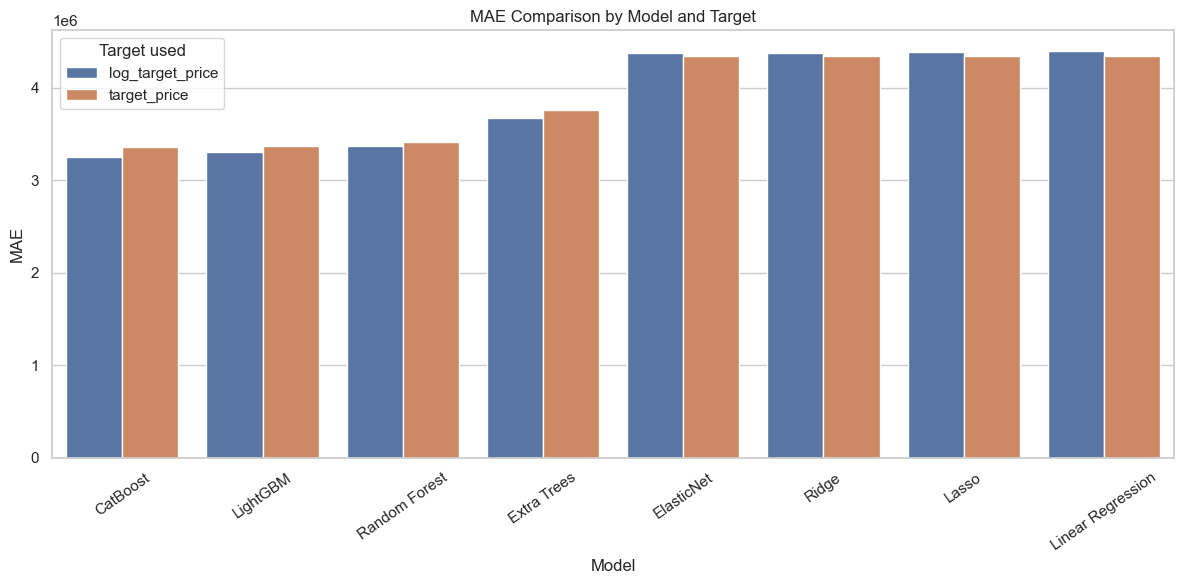

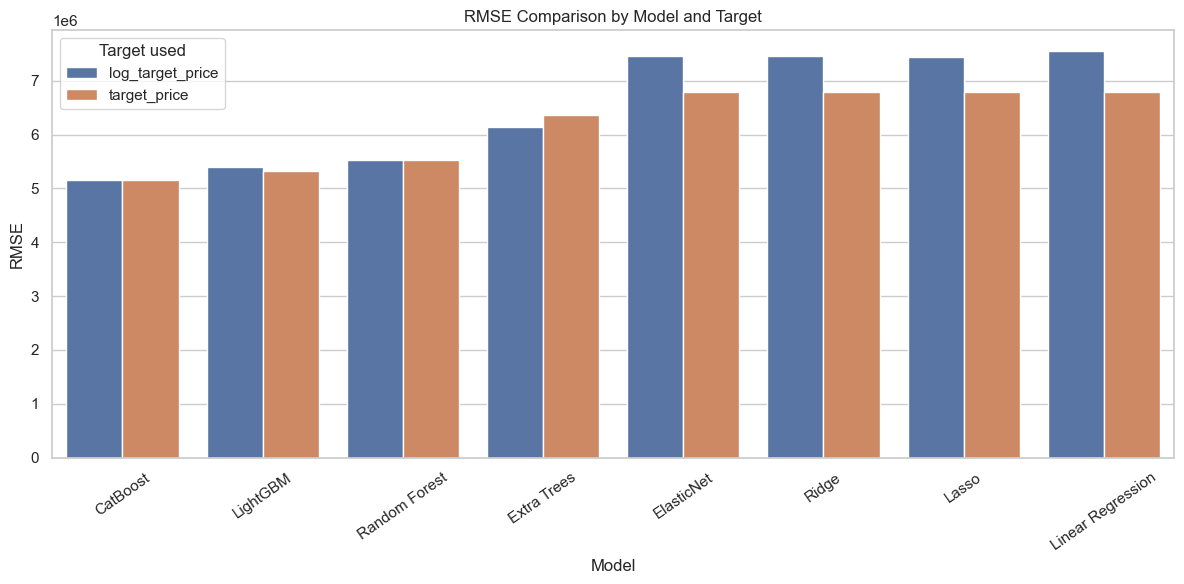

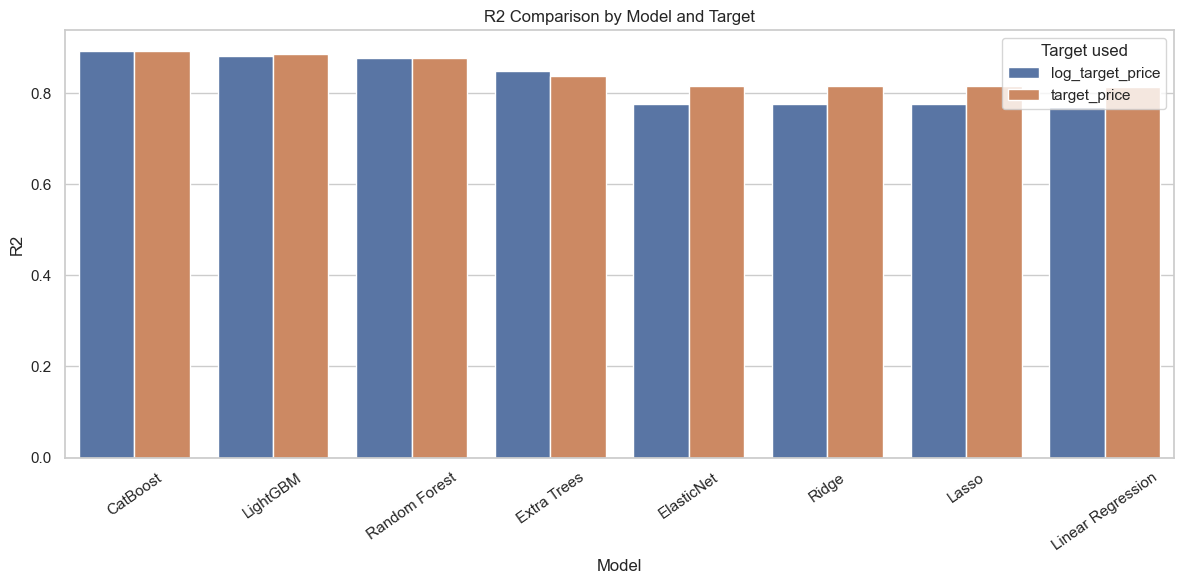

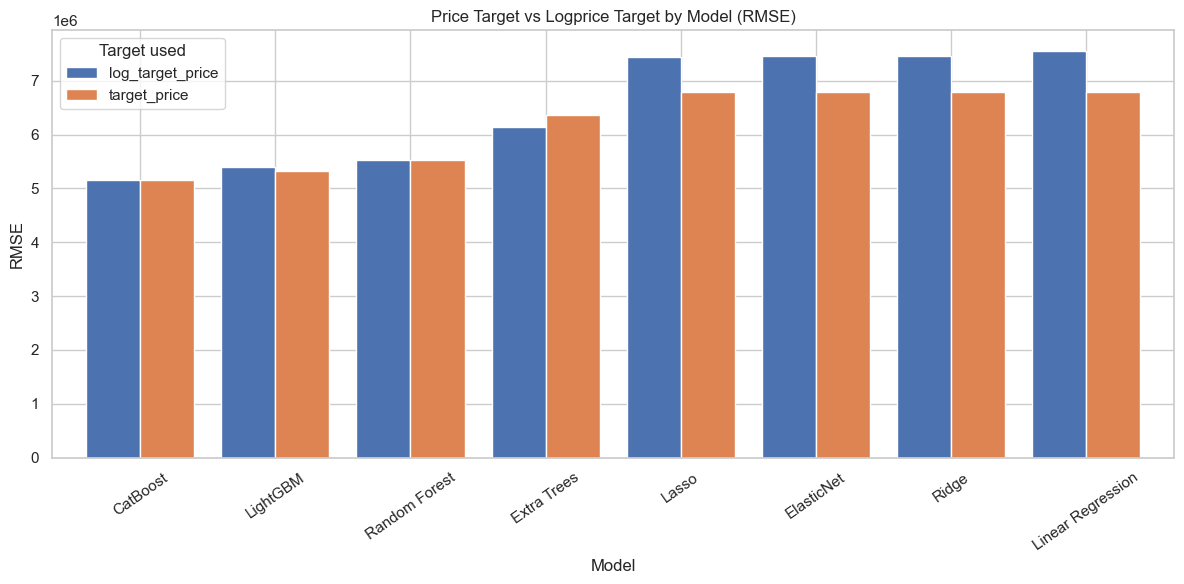

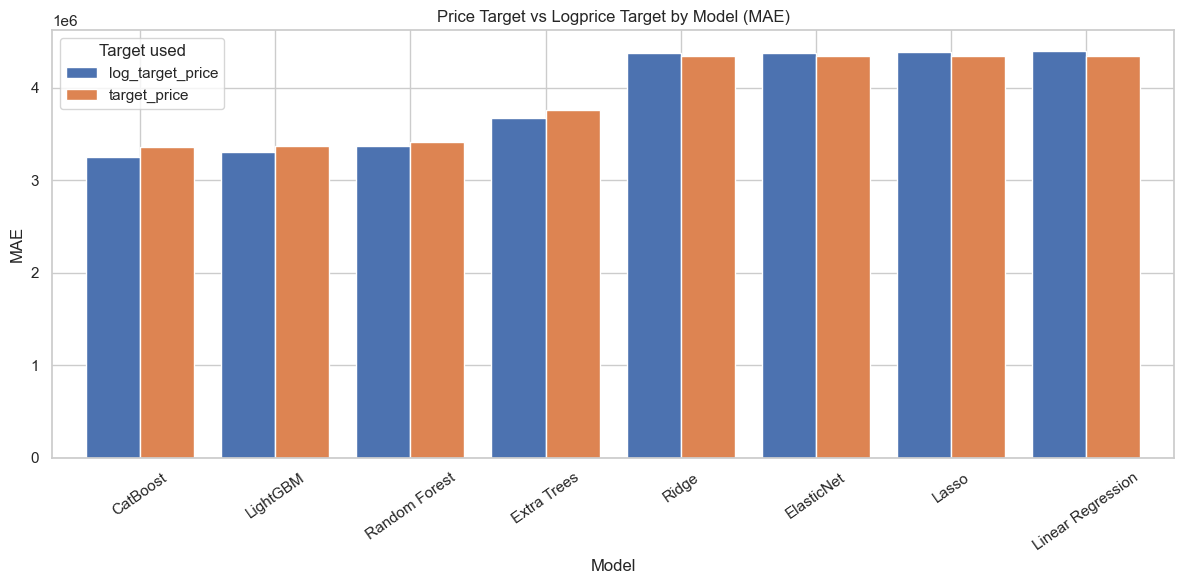

In [137]:
for metric in ['mae', 'rmse', 'r2']:
    plot_metric_comparison(metrics_df, metric)

plot_target_comparison(metrics_df, metric_name='rmse')
plot_target_comparison(metrics_df, metric_name='mae')

## Target Strategy Comparison

Các biểu đồ trên so sánh hiệu năng của từng mô hình khi train trực tiếp trên `target_price` và khi train trên `log_target_price`, sau đó chuyển prediction ngược về thang giá gốc để đánh giá. Vì MAE, RMSE và R² đều được tính trên cùng một thang đo giá gốc, các kết quả này có thể so sánh trực tiếp với nhau.

Nhìn chung, nhóm mô hình boosting như `CatBoost` và `LightGBM` vẫn là nhóm có hiệu năng tốt nhất. Hai mô hình này đạt MAE và RMSE thấp nhất trong toàn bộ các mô hình, đồng thời giữ R² cao nhất. Điều này cho thấy các mô hình gradient boosting phù hợp hơn với bài toán dự đoán giá laptop so với các mô hình tuyến tính.

Với `CatBoost`, sự khác biệt giữa `target_price` và `log_target_price` là rất nhỏ. Phiên bản `log_target_price` có MAE thấp hơn một chút, trong khi RMSE gần như tương đương với phiên bản train trực tiếp trên `target_price`. Điều này cho thấy log-transform có thể giúp mô hình dự đoán ổn định hơn ở sai số trung bình, nhưng không tạo ra khác biệt quá lớn về tổng thể.

Với `LightGBM` và `Random Forest`, kết quả giữa hai target cũng khá gần nhau. `log_target_price` thường giúp giảm MAE nhẹ, nhưng RMSE có thể không luôn tốt hơn. Điều này cho thấy log-transform không phải lúc nào cũng cải thiện toàn bộ metric, mà chủ yếu giúp giảm ảnh hưởng của các giá trị giá quá lớn và làm mô hình dự đoán cân bằng hơn theo tỷ lệ.

Ở nhóm linear models như `Linear Regression`, `Ridge`, `Lasso` và `ElasticNet`, việc train trên `log_target_price` cho kết quả kém hơn rõ rệt khi đánh giá lại trên thang giá gốc. RMSE tăng lên đáng kể và R² giảm xuống. Điều này cho thấy các mô hình tuyến tính không xử lý tốt việc chuyển đổi log-target trong bài toán này, đặc biệt khi cần tối ưu sai số tuyệt đối trên giá gốc.

Biểu đồ R² cũng củng cố kết luận này. Các mô hình tree-based ensemble duy trì R² cao hơn, trong khi nhóm linear models giảm hiệu năng khi dùng `log_target_price`. Vì vậy, linear models chỉ nên được xem là baseline tham khảo, không phải nhóm mô hình chính để lựa chọn cuối cùng.

Tổng thể, `CatBoost` là mô hình ổn định nhất giữa hai cách biểu diễn target. `LightGBM` cũng là ứng viên mạnh nhờ hiệu năng gần với CatBoost và thời gian train nhanh. Đối với các bước tiếp theo như feature selection và hyperparameter tuning, nên ưu tiên `CatBoost` và `LightGBM`, trong đó `log_target_price` có thể được giữ lại như một chiến lược target chính để thử nghiệm tiếp.

## 16. Generate actual vs predicted plots for top 3 models

Scatter plot Actual vs Predicted cho top 3 model giúp kiểm tra trực quan mức độ bám sát đường lý tưởng `y = x`. Nếu điểm lệch mạnh ở vùng giá cao hoặc giá thấp, đó là dấu hiệu nên phân tích thêm theo phân khúc laptop thay vì chỉ nhìn metric tổng thể.

,model_name,target_used,rmse,mae,r2
0,CatBoost,log_target_price,"5,157,061.3893","3,252,280.8663",0.8930
1,CatBoost,target_price,"5,162,384.4059","3,362,703.2339",0.8928
2,LightGBM,target_price,"5,322,802.4342","3,371,062.7982",0.8860


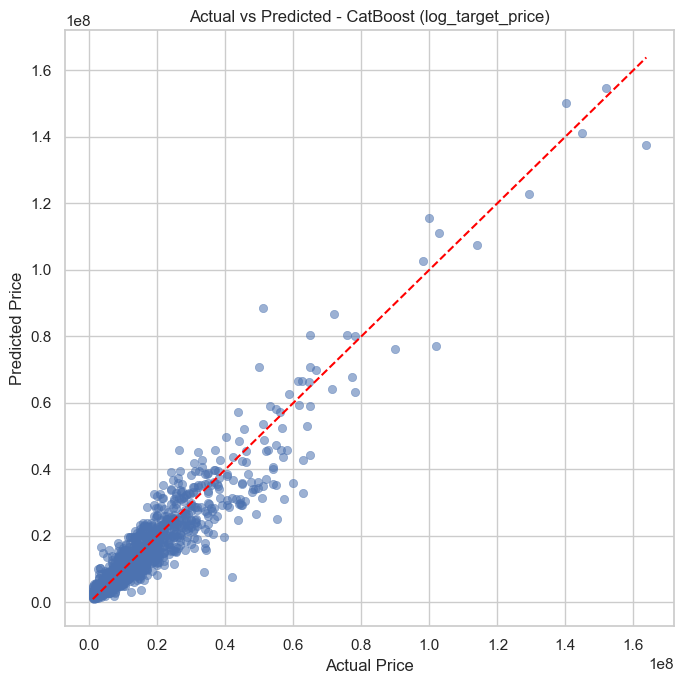

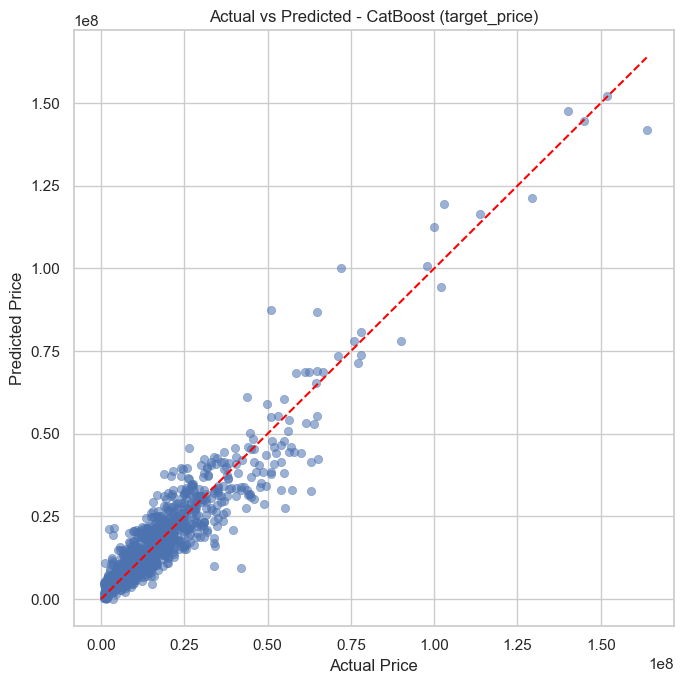

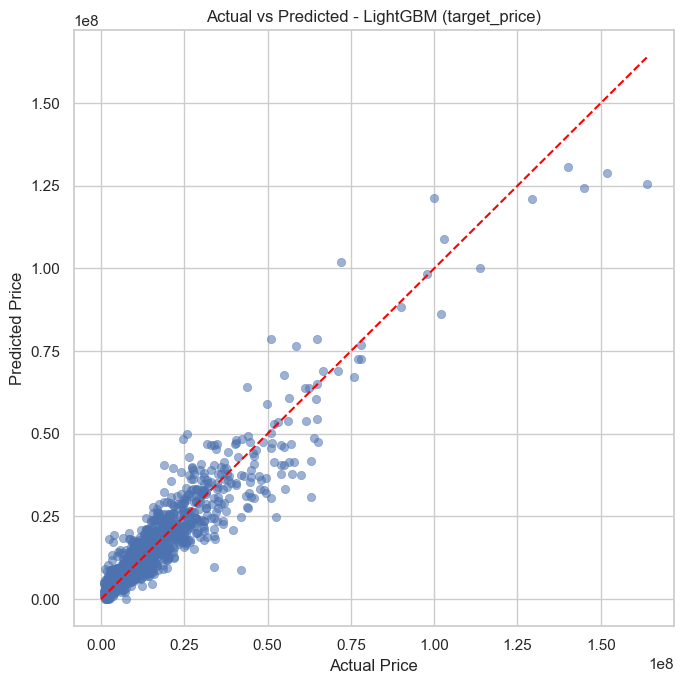

In [138]:
top_3_models = metrics_df.sort_values('rmse').head(3)[['model_name', 'target_used', 'rmse', 'mae', 'r2']]
display(top_3_models)

for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    plot_actual_vs_predicted(
        y_true=y_price_test,
        y_pred=predictions_df[pred_col].values,
        model_name=row['model_name'],
        target_used=row['target_used'],
    )

## Actual vs Predicted Analysis

Các biểu đồ `Actual vs Predicted` so sánh giá thật với giá dự đoán của mô hình `CatBoost`. Đường gạch đỏ thể hiện đường dự đoán lý tưởng, tức là `predicted price = actual price`. Điểm càng nằm gần đường này thì mô hình dự đoán càng chính xác.

Nhìn chung, các điểm dữ liệu tập trung khá sát quanh đường chéo, đặc biệt ở vùng giá thấp và trung bình. Điều này cho thấy `CatBoost` học được xu hướng chính của dữ liệu và có khả năng dự đoán tương đối tốt trên phần lớn laptop trong test set.

Tuy nhiên, khi giá thực tế tăng cao, các điểm bắt đầu phân tán rộng hơn. Điều này cho thấy mô hình gặp khó khăn hơn với các laptop giá cao. Đây là hiện tượng khá phổ biến trong bài toán dự đoán giá, vì nhóm sản phẩm cao cấp thường ít mẫu hơn, có cấu hình đặc biệt hơn, và dễ bị ảnh hưởng bởi các yếu tố chưa được biểu diễn đầy đủ trong feature.

So sánh giữa `CatBoost` dùng `log_target_price` và `CatBoost` dùng trực tiếp `target_price`, hai biểu đồ có pattern khá giống nhau. Cả hai đều dự đoán tốt ở vùng giá phổ biến và đều có sai số lớn hơn ở vùng giá cao. Phiên bản `log_target_price` có xu hướng ổn định hơn ở vùng giá thấp đến trung bình, trong khi phiên bản `target_price` có một số điểm giá cao bám khá sát đường lý tưởng.

Một số điểm nằm xa đường chéo cho thấy mô hình vẫn có các trường hợp overestimate hoặc underestimate đáng kể. Những điểm nằm phía trên đường đỏ là các mẫu bị dự đoán cao hơn giá thật, còn những điểm nằm phía dưới đường đỏ là các mẫu bị dự đoán thấp hơn giá thật. Các mẫu này nên được phân tích thêm trong bước residual analysis để xác định liệu chúng là outlier, laptop cao cấp, brand đặc biệt, hay các dòng máy có thông tin cấu hình chưa đủ rõ.

Tổng thể, biểu đồ xác nhận rằng `CatBoost` là một baseline mạnh cho bài toán này. Mô hình dự đoán tốt trên phần lớn khoảng giá, nhưng vẫn cần phân tích lỗi ở nhóm laptop giá cao và các outlier trước khi chọn mô hình cuối cùng.

## 17. Generate residual and error distribution plots for top 3 models

Residual plot cho biết sai số có phân bố ngẫu nhiên hay bị lệch theo mức giá dự đoán. Error distribution plot giúp quan sát bias tổng thể: phân phối centered gần 0 là tốt, còn lệch hẳn sang một phía cho thấy model có xu hướng overestimate hoặc underestimate.

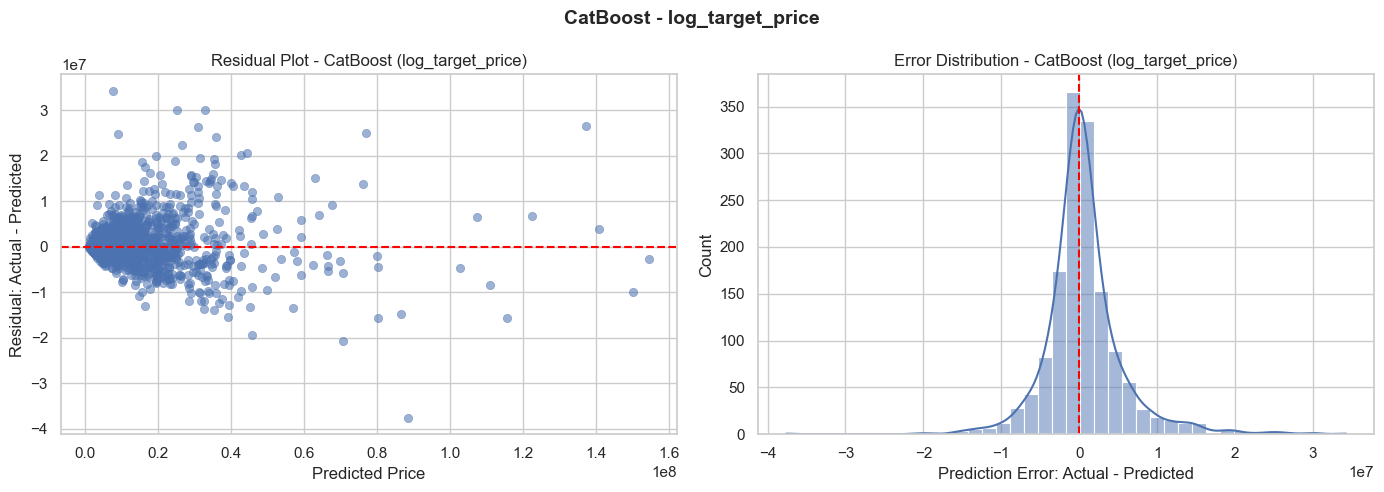

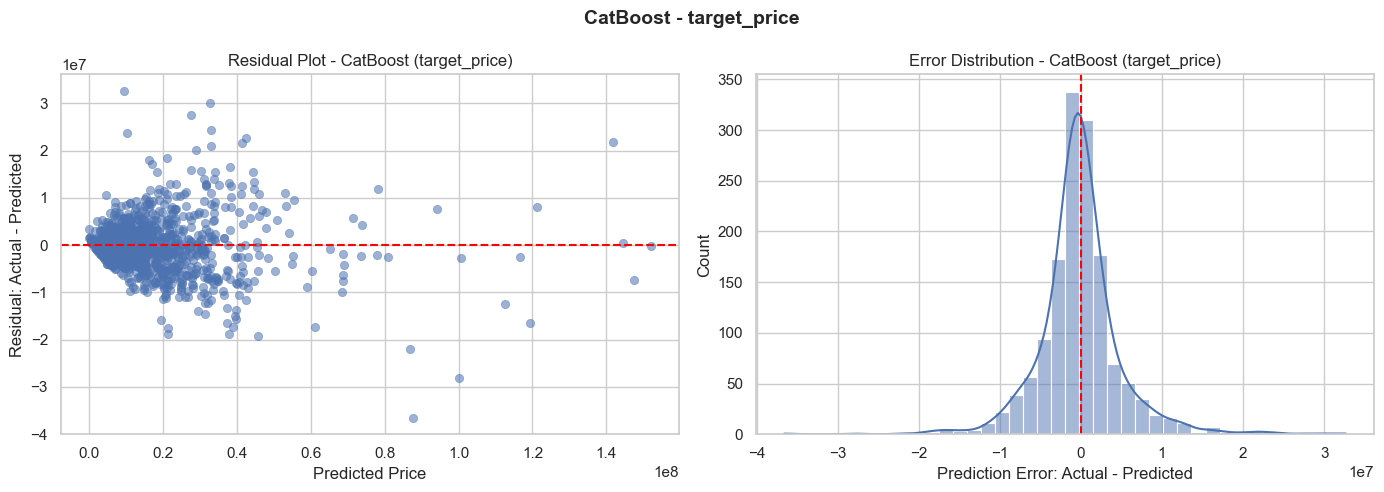

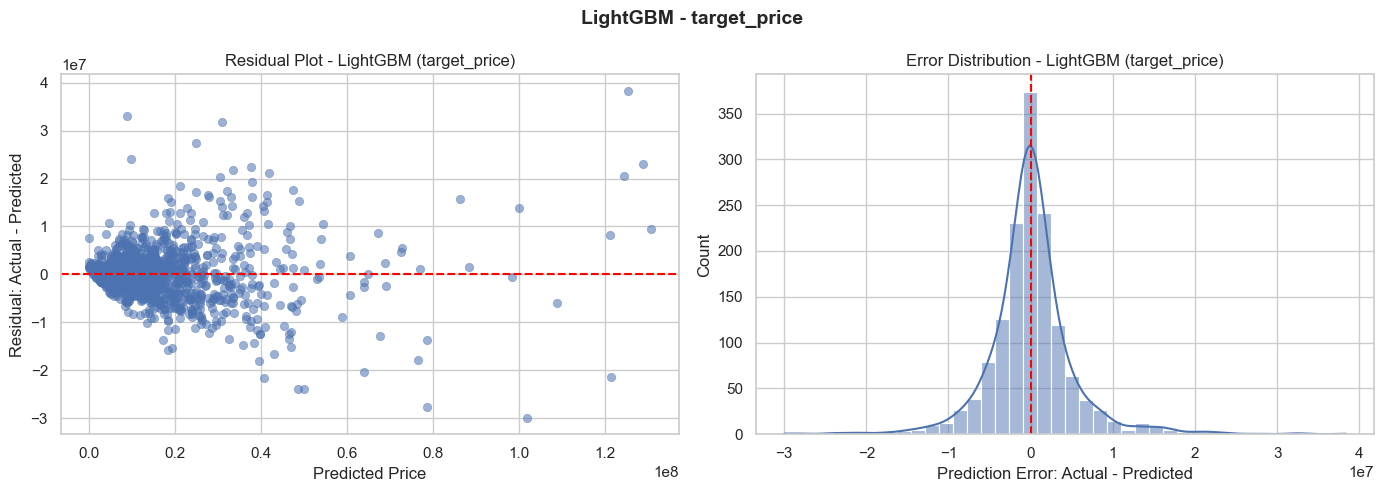

In [139]:
for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    y_pred_current = predictions_df[pred_col].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_residuals(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[0]
    )

    plot_error_distribution(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[1]
    )

    fig.suptitle(
        f"{row['model_name']} - {row['target_used']}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

## 18. Save feature importance / coefficients

Với tree-based model, notebook lưu `feature_importances_`; với linear model, notebook lưu coefficient table. Cột `abs_importance` hỗ trợ sắp xếp độ ảnh hưởng tuyệt đối, nhưng khi diễn giải linear coefficient vẫn nên chú ý dấu âm/dương của cột `importance`.

In [140]:
feature_importance_frames = []

for model_key, fitted_model in trained_models.items():
    model_name, target_used = model_key.rsplit('_', 1)
    importance_df = extract_feature_importance(fitted_model, model_name, feature_names)

    if importance_df is None:
        print(f'No feature importance or coefficients available for {model_key}.')
        continue

    importance_df['target_used'] = target_used
    output_columns = ['feature', 'importance', 'model_name', 'target_used', 'importance_type', 'abs_importance']
    importance_df = importance_df[output_columns]

    output_path = FEATURE_IMPORTANCE_DIR / f'{safe_filename(model_name, target_used)}_feature_importance.csv'
    importance_df.to_csv(output_path, index=False)
    feature_importance_frames.append(importance_df)
    print(f'Saved: {output_path.name}')

if feature_importance_frames:
    all_feature_importance_df = pd.concat(feature_importance_frames, ignore_index=True)
    all_feature_importance_path = FEATURE_IMPORTANCE_DIR / 'all_feature_importance.csv'
    all_feature_importance_df.to_csv(all_feature_importance_path, index=False)
    display(all_feature_importance_df.head(20))
else:
    all_feature_importance_df = pd.DataFrame()

Saved: LinearRegression_target_price_feature_importance.csv
Saved: LinearRegression_log_target_price_feature_importance.csv
Saved: Ridge_target_price_feature_importance.csv
Saved: Ridge_log_target_price_feature_importance.csv
Saved: Lasso_target_price_feature_importance.csv
Saved: Lasso_log_target_price_feature_importance.csv
Saved: ElasticNet_target_price_feature_importance.csv
Saved: ElasticNet_log_target_price_feature_importance.csv
Saved: RandomForest_target_price_feature_importance.csv
Saved: RandomForest_log_target_price_feature_importance.csv
Saved: ExtraTrees_target_price_feature_importance.csv
Saved: ExtraTrees_log_target_price_feature_importance.csv
Saved: LightGBM_target_price_feature_importance.csv
Saved: LightGBM_log_target_price_feature_importance.csv
Saved: CatBoost_target_price_feature_importance.csv
Saved: CatBoost_log_target_price_feature_importance.csv


,feature,importance,model_name,target_used,importance_type,abs_importance
0,condition_Đã sử dụng (chưa sửa chữa),"138,479,328,888,350,130,176.0000",Linear Regression_target,price,coefficient,"138,479,328,888,350,130,176.0000"
1,gpu_type_Integrated,"89,090,920,233,866,018,816.0000",Linear Regression_target,price,coefficient,"89,090,920,233,866,018,816.0000"
2,gpu_type_Missing_Info,"81,415,254,169,432,637,440.0000",Linear Regression_target,price,coefficient,"81,415,254,169,432,637,440.0000"
3,gpu_type_Dedicated,"77,515,519,470,976,729,088.0000",Linear Regression_target,price,coefficient,"77,515,519,470,976,729,088.0000"
4,warranty_not_active,"58,619,096,831,264,423,936.0000",Linear Regression_target,price,coefficient,"58,619,096,831,264,423,936.0000"
5,brand_Dell,"56,779,843,691,038,851,072.0000",Linear Regression_target,price,coefficient,"56,779,843,691,038,851,072.0000"
6,condition_Mới,"45,799,372,160,784,564,224.0000",Linear Regression_target,price,coefficient,"45,799,372,160,784,564,224.0000"
7,brand_Lenovo,"44,615,978,763,806,883,840.0000",Linear Regression_target,price,coefficient,"44,615,978,763,806,883,840.0000"
8,brand_Apple,"43,917,313,881,991,413,760.0000",Linear Regression_target,price,coefficient,"43,917,313,881,991,413,760.0000"
9,brand_HP,"42,743,889,622,958,972,928.0000",Linear Regression_target,price,coefficient,"42,743,889,622,958,972,928.0000"


## 19. Summary of best models

Phần cuối notebook tổng hợp top model theo RMSE và MAE, so sánh `price` với `logprice` trong từng thuật toán, rồi in kết luận tự động. Kết luận có kiểm tra khoảng cách giữa các model top đầu; nếu chênh lệch nhỏ, notebook sẽ ghi rõ rằng kết quả nên được xem là sát nhau thay vì khẳng định tuyệt đối.

In [141]:
top_by_rmse = metrics_df.sort_values('rmse').head(10).reset_index(drop=True)
top_by_mae = metrics_df.sort_values('mae').head(10).reset_index(drop=True)

display(top_by_rmse)
display(top_by_mae)

# Compare price vs logprice target for each model.
target_comparison_rows = []
for model_name, group in metrics_df.groupby('model_name'):
    pivot = group.set_index('target_used')
    if {'target_price', 'log_target_price'}.issubset(pivot.index):
        price_rmse = pivot.loc['target_price', 'rmse']
        log_rmse = pivot.loc['log_target_price', 'rmse']
        price_mae = pivot.loc['target_price', 'mae']
        log_mae = pivot.loc['log_target_price', 'mae']
        target_comparison_rows.append(
            {
                'model_name': model_name,
                'price_rmse': price_rmse,
                'logprice_rmse': log_rmse,
                'rmse_winner': 'log_target_price' if log_rmse < price_rmse else 'target_price',
                'rmse_pct_diff_log_vs_price': (log_rmse - price_rmse) / price_rmse,
                'price_mae': price_mae,
                'logprice_mae': log_mae,
                'mae_winner': 'log_target_price' if log_mae < price_mae else 'target_price',
                'mae_pct_diff_log_vs_price': (log_mae - price_mae) / price_mae,
            }
        )

target_comparison_df = pd.DataFrame(target_comparison_rows).sort_values('model_name')
display(target_comparison_df)

best_rmse_row = metrics_df.loc[metrics_df['rmse'].idxmin()]
best_mae_row = metrics_df.loc[metrics_df['mae'].idxmin()]

target_summary = metrics_df.groupby('target_used')[['rmse', 'mae', 'r2']].mean().sort_values('rmse')
best_target_overall = target_summary.index[0]

rmse_gap = (
    metrics_df.sort_values('rmse').iloc[1]['rmse'] - best_rmse_row['rmse']
) / best_rmse_row['rmse'] if len(metrics_df) > 1 else np.nan

mae_gap = (
    metrics_df.sort_values('mae').iloc[1]['mae'] - best_mae_row['mae']
) / best_mae_row['mae'] if len(metrics_df) > 1 else np.nan

print('Automatic conclusion')
print('--------------------')
print(
    f"Best model by RMSE: {best_rmse_row['model_name']} trained on {best_rmse_row['target_used']} "
    f"with RMSE={best_rmse_row['rmse']:,.4f}, MAE={best_rmse_row['mae']:,.4f}, R2={best_rmse_row['r2']:,.4f}."
)
print(
    f"Best model by MAE : {best_mae_row['model_name']} trained on {best_mae_row['target_used']} "
    f"with MAE={best_mae_row['mae']:,.4f}, RMSE={best_mae_row['rmse']:,.4f}, R2={best_mae_row['r2']:,.4f}."
)
print(f"Best target overall by average RMSE across models: {best_target_overall}.")

if not np.isnan(rmse_gap) and rmse_gap < 0.02:
    print('RMSE difference between the top two variants is below 2%, so the winner should be treated as a close result.')
if not np.isnan(mae_gap) and mae_gap < 0.02:
    print('MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.')

if best_target_overall == 'log_target_price':
    print('Recommendation: logprice is currently preferable on average, but confirm with residual plots and business tolerance for large-price errors.')
else:
    print('Recommendation: direct price modeling is currently preferable on average, but confirm with residual plots and segment-level errors.')

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,log_target_price,target_price,"3,252,280.8663","5,157,061.3893",0.8930,0.2771,"1,916,663.0917","37,608,943.3134",1.1344,0.0022
1,CatBoost,gradient_boosting,target_price,target_price,"3,362,703.2339","5,162,384.4059",0.8928,0.3314,"2,039,510.9310","36,580,025.3383",1.1833,0.0048
2,LightGBM,gradient_boosting,target_price,target_price,"3,371,062.7982","5,322,802.4342",0.8860,0.3160,"2,007,119.7696","38,350,151.4341",0.5240,0.0102
3,LightGBM,gradient_boosting,log_target_price,target_price,"3,309,789.3388","5,407,378.8236",0.8823,0.2770,"1,868,291.6436","40,782,927.3785",0.3695,0.0111
4,Random Forest,tree_ensemble,target_price,target_price,"3,412,705.0440","5,526,455.5762",0.8771,0.3124,"1,915,382.6300","48,433,650.0000",1.3356,0.1569
5,Random Forest,tree_ensemble,log_target_price,target_price,"3,367,907.0407","5,530,209.9654",0.8769,0.2901,"1,899,621.9828","38,524,138.4898",1.2858,0.1107
6,Extra Trees,tree_ensemble,log_target_price,target_price,"3,670,282.7920","6,143,809.8092",0.8481,0.3143,"1,994,764.5704","57,489,239.1507",1.4723,0.1393
7,Extra Trees,tree_ensemble,target_price,target_price,"3,766,407.0975","6,361,692.6960",0.8371,0.3357,"2,000,000.0000","68,972,766.6667",1.3908,0.1240
8,ElasticNet,linear,target_price,target_price,"4,340,622.3989","6,784,919.8876",0.8148,0.4449,"2,705,409.5432","77,725,809.6648",2.9982,0.0048
9,Ridge,linear,target_price,target_price,"4,340,805.3332","6,786,909.3092",0.8147,0.4450,"2,714,108.6220","77,900,063.2654",0.0215,0.0051


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,log_target_price,target_price,"3,252,280.8663","5,157,061.3893",0.8930,0.2771,"1,916,663.0917","37,608,943.3134",1.1344,0.0022
1,LightGBM,gradient_boosting,log_target_price,target_price,"3,309,789.3388","5,407,378.8236",0.8823,0.2770,"1,868,291.6436","40,782,927.3785",0.3695,0.0111
2,CatBoost,gradient_boosting,target_price,target_price,"3,362,703.2339","5,162,384.4059",0.8928,0.3314,"2,039,510.9310","36,580,025.3383",1.1833,0.0048
3,Random Forest,tree_ensemble,log_target_price,target_price,"3,367,907.0407","5,530,209.9654",0.8769,0.2901,"1,899,621.9828","38,524,138.4898",1.2858,0.1107
4,LightGBM,gradient_boosting,target_price,target_price,"3,371,062.7982","5,322,802.4342",0.8860,0.3160,"2,007,119.7696","38,350,151.4341",0.5240,0.0102
5,Random Forest,tree_ensemble,target_price,target_price,"3,412,705.0440","5,526,455.5762",0.8771,0.3124,"1,915,382.6300","48,433,650.0000",1.3356,0.1569
6,Extra Trees,tree_ensemble,log_target_price,target_price,"3,670,282.7920","6,143,809.8092",0.8481,0.3143,"1,994,764.5704","57,489,239.1507",1.4723,0.1393
7,Extra Trees,tree_ensemble,target_price,target_price,"3,766,407.0975","6,361,692.6960",0.8371,0.3357,"2,000,000.0000","68,972,766.6667",1.3908,0.1240
8,ElasticNet,linear,target_price,target_price,"4,340,622.3989","6,784,919.8876",0.8148,0.4449,"2,705,409.5432","77,725,809.6648",2.9982,0.0048
9,Ridge,linear,target_price,target_price,"4,340,805.3332","6,786,909.3092",0.8147,0.4450,"2,714,108.6220","77,900,063.2654",0.0215,0.0051


,model_name,price_rmse,logprice_rmse,rmse_winner,rmse_pct_diff_log_vs_price,price_mae,logprice_mae,mae_winner,mae_pct_diff_log_vs_price
0,CatBoost,"5,162,384.4059","5,157,061.3893",log_target_price,-0.0010,"3,362,703.2339","3,252,280.8663",log_target_price,-0.0328
1,ElasticNet,"6,784,919.8876","7,456,199.7408",target_price,0.0989,"4,340,622.3989","4,382,125.4323",target_price,0.0096
2,Extra Trees,"6,361,692.6960","6,143,809.8092",log_target_price,-0.0342,"3,766,407.0975","3,670,282.7920",log_target_price,-0.0255
3,Lasso,"6,787,956.8235","7,449,210.3643",target_price,0.0974,"4,340,923.2558","4,386,154.3769",target_price,0.0104
4,LightGBM,"5,322,802.4342","5,407,378.8236",target_price,0.0159,"3,371,062.7982","3,309,789.3388",log_target_price,-0.0182
5,Linear Regression,"6,794,584.8084","7,559,818.1086",target_price,0.1126,"4,349,698.9763","4,402,312.3943",target_price,0.0121
6,Random Forest,"5,526,455.5762","5,530,209.9654",target_price,0.0007,"3,412,705.0440","3,367,907.0407",log_target_price,-0.0131
7,Ridge,"6,786,909.3092","7,459,288.9652",target_price,0.0991,"4,340,805.3332","4,380,500.4178",target_price,0.0091


Automatic conclusion
--------------------
Best model by RMSE: CatBoost trained on log_target_price with RMSE=5,157,061.3893, MAE=3,252,280.8663, R2=0.8930.
Best model by MAE : CatBoost trained on log_target_price with MAE=3,252,280.8663, RMSE=5,157,061.3893, R2=0.8930.
Best target overall by average RMSE across models: target_price.
RMSE difference between the top two variants is below 2%, so the winner should be treated as a close result.
MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.
Recommendation: direct price modeling is currently preferable on average, but confirm with residual plots and segment-level errors.
